In [101]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import savemat
import os


from importlib import reload
import kan
reload(kan)

from kan import KAN

## Multi-input, multi-output regression test

This test evaluates the tanh-basis KAN on a simple 2D regression task with two outputs.  
The inputs satisfy $x_1, x_2 \in (0,1]$, and the target functions are

$$
y_1 = \sin(4x_1) + 0.5x_2^2
$$

$$
y_2 = 0.3x_1^2 + \cos(3x_2)
$$

These targets are nonlinear but still additive across input coordinates, which matches the structure of a one-layer KAN:
$$
y_j = \sum_i \varphi_{ij}(x_i)
$$

In [102]:
x_min_test = 0
x_max_test = 1

In [103]:
mat_path = "activation_KAN_fit_B_Sofija_extend_positive_basisKAN.mat"

b_coef, input_power, peakout_data, set_detuning = kan.load_photonic_activation_data(mat_path)

#selected_indices = kan.select_equidistant_basis_indices(
#    total_basis=b_coef.shape[0],
#    num_selected=12,
#)
selected_indices = np.arange(10)

b_coef_selected = b_coef[selected_indices]

print("Selected indices:", selected_indices)
print("Selected detunings:", set_detuning[selected_indices])
print("Selected b_coef shape:", b_coef_selected.shape)

mat_folder = "2-2_exports"
os.makedirs(mat_folder, exist_ok=True)

Selected indices: [0 1 2 3 4 5 6 7 8 9]
Selected detunings: tensor([-5.0000e+10, -6.0000e+10, -7.0000e+10, -8.0000e+10, -9.0000e+10,
        -1.0000e+11, -1.1000e+11, -1.2000e+11, -1.3000e+11, -1.4000e+11])
Selected b_coef shape: torch.Size([10, 8])


In [104]:
torch.manual_seed(42)

n_train = 1000
n_test = 300

x_train = x_min_test + x_max_test * torch.rand(n_train, 2)
x_test = x_min_test + x_max_test * torch.rand(n_test, 2)

def target_fn(x):
    x1 = x[:, 0:1]
    x2 = x[:, 1:2]

    x1n = x1 / x_max_test
    x2n = x2 / x_max_test

    y1 = torch.sin(4.0 * x1n) + 0.5 * x2n**2
    y2 = 0.3 * x1n**2 + torch.cos(3.0 * x2n)

    return torch.cat([y1, y2], dim=1)

y_train = target_fn(x_train)
y_test = target_fn(x_test)

In [105]:
model = KAN(
    in_count=2,
    out_count=2,
    hidden_layer_sizes=[],
    layer_type="photonic",
    b_coef_selected=b_coef_selected,
    x_min=float(input_power.min()),
    x_max=float(input_power.max()),
    dropout_prob=0.0,
    normalize_basis=False,
    check_input_range=True,
    debug=False,
)

In [106]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device=device, dtype=torch.float64)

x_train = x_train.to(device=device, dtype=torch.float64)
y_train = y_train.to(device=device, dtype=torch.float64)

In [107]:
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()

num_epochs = 2500
train_losses = []
test_losses = []

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    y_pred = model(x_train)
    loss = loss_fn(y_pred, y_train)
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.no_grad():
        y_test_pred = model(x_test)
        test_loss = loss_fn(y_test_pred, y_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())

    if epoch % 250 == 0:
        print(
            f"Epoch {epoch:4d} | "
            f"train loss = {loss.item():.6f} | "
            f"test loss = {test_loss.item():.6f}"
        )

Epoch    0 | train loss = 0.562033 | test loss = 0.362189
Epoch  250 | train loss = 0.008034 | test loss = 0.007051
Epoch  500 | train loss = 0.006216 | test loss = 0.005208
Epoch  750 | train loss = 0.005603 | test loss = 0.004599
Epoch 1000 | train loss = 0.005277 | test loss = 0.004258
Epoch 1250 | train loss = 0.005081 | test loss = 0.004041
Epoch 1500 | train loss = 0.004936 | test loss = 0.003871
Epoch 1750 | train loss = 0.004838 | test loss = 0.003749
Epoch 2000 | train loss = 0.004807 | test loss = 0.003673
Epoch 2250 | train loss = 0.004687 | test loss = 0.003554


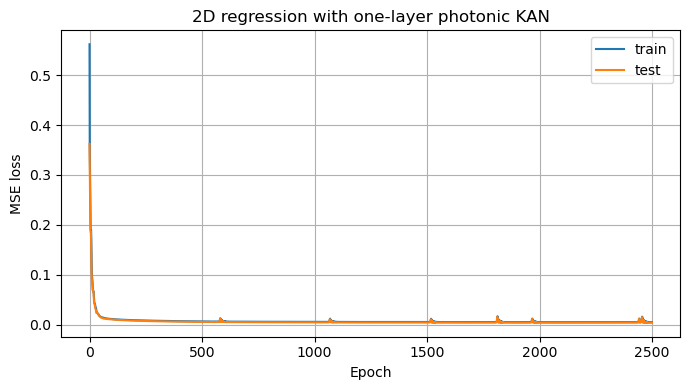

In [108]:
savemat(
    os.path.join(mat_folder, "loss_curves.mat"),
    {
        "plot_type": "loss_curves",
        "epoch": np.arange(num_epochs),
        "train_losses": np.array(train_losses),
        "test_losses": np.array(test_losses),
        "num_epochs": num_epochs,
    },
)

plt.figure(figsize=(7, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("2D regression with one-layer photonic KAN")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

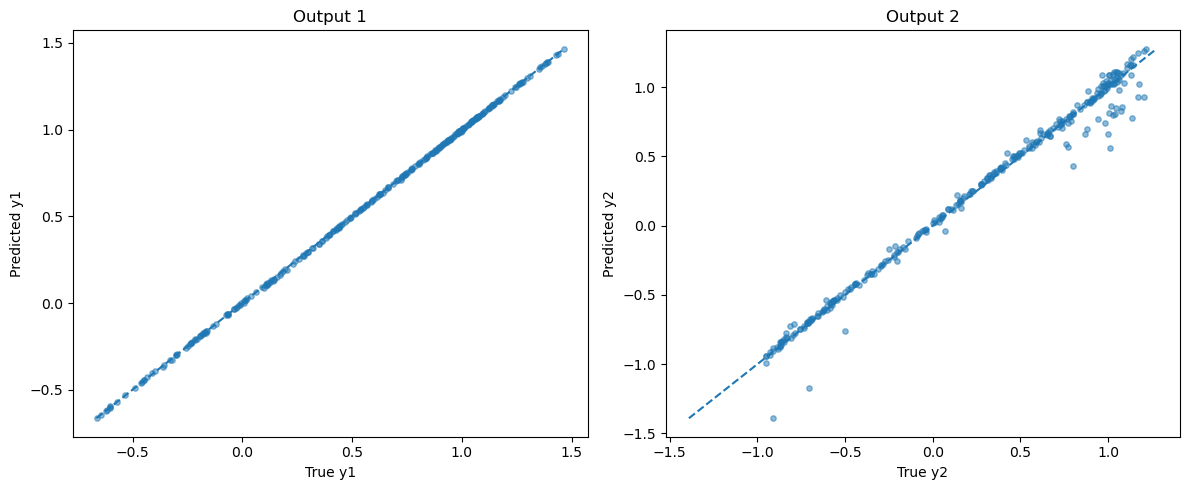

In [109]:
model.eval()
with torch.no_grad():
    y_pred_test = model(x_test)

savemat(
    os.path.join(mat_folder, "true_vs_pred_test.mat"),
    {
        "plot_type": "true_vs_pred_test",
        "x_test": x_test.detach().cpu().numpy(),
        "y_test": y_test.detach().cpu().numpy(),
        "y_pred_test": y_pred_test.detach().cpu().numpy(),
    },
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for j in range(2):
    axes[j].scatter(y_test[:, j].numpy(), y_pred_test[:, j].numpy(), alpha=0.5, s=15)
    minv = min(y_test[:, j].min().item(), y_pred_test[:, j].min().item())
    maxv = max(y_test[:, j].max().item(), y_pred_test[:, j].max().item())
    axes[j].plot([minv, maxv], [minv, maxv], linestyle="--")
    axes[j].set_xlabel(f"True y{j+1}")
    axes[j].set_ylabel(f"Predicted y{j+1}")
    axes[j].set_title(f"Output {j+1}")

plt.tight_layout()
plt.show()

Saved MATLAB plot data to: 2-2_exports/basis_L0_in0.mat


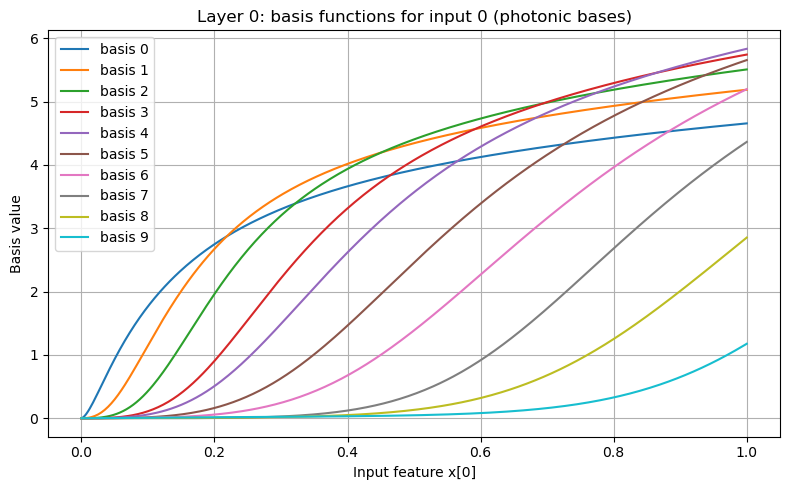

Saved MATLAB plot data to: 2-2_exports/basis_L0_in1.mat


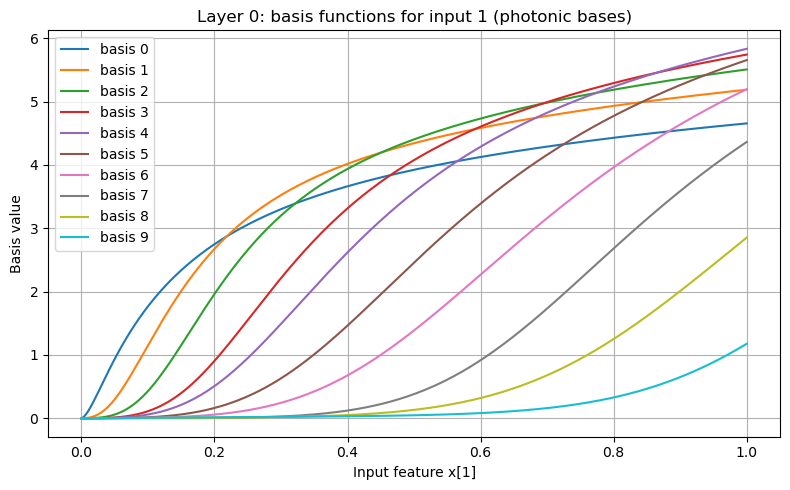

basis shape: torch.Size([400, 10])
basis finite: True
phi finite: True
Saved MATLAB plot data to: 2-2_exports/edge_L0_out0_in0.mat


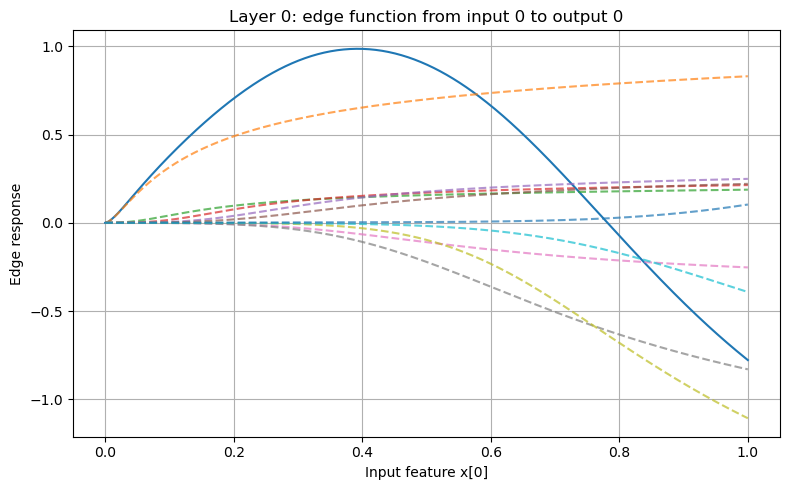

basis shape: torch.Size([400, 10])
basis finite: True
phi finite: True
Saved MATLAB plot data to: 2-2_exports/edge_L0_out0_in1.mat


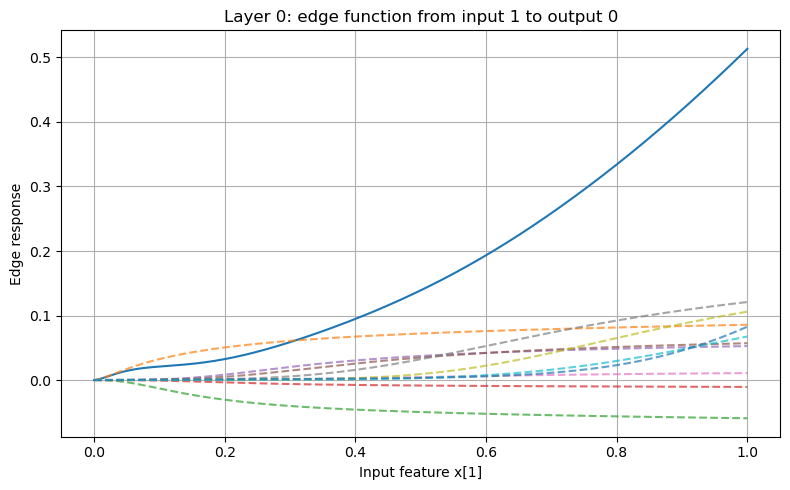

basis shape: torch.Size([400, 10])
basis finite: True
phi finite: True
Saved MATLAB plot data to: 2-2_exports/edge_L0_out1_in0.mat


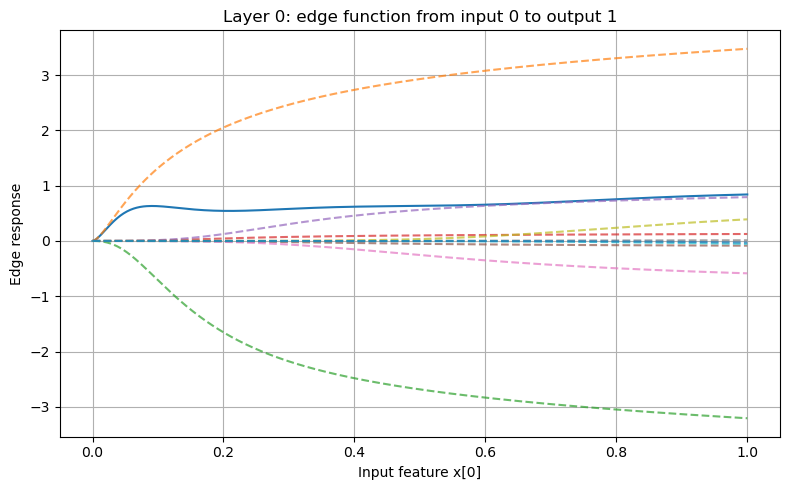

basis shape: torch.Size([400, 10])
basis finite: True
phi finite: True
Saved MATLAB plot data to: 2-2_exports/edge_L0_out1_in1.mat


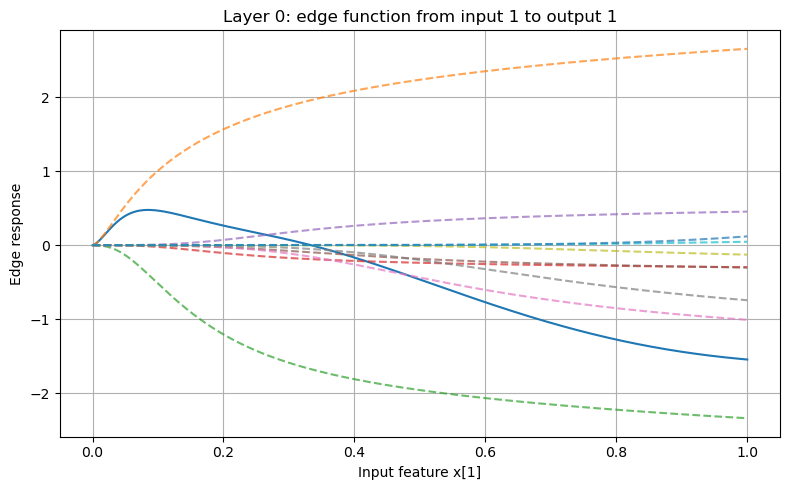

In [110]:
model.plot_basis_functions(layer_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), mat_export_path="basis_L0_in0.mat", mat_export_dir=mat_folder)
model.plot_basis_functions(layer_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), mat_export_path="basis_L0_in1.mat", mat_export_dir=mat_folder)

model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=0, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=0, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_L0_out1_in0.mat", mat_export_dir=mat_folder)
model.plot_edge_function(layer_idx=0, out_idx=1, in_idx=1, x_range=(x_min_test, x_max_test), show_basis=True, mat_export_path="edge_L0_out1_in1.mat", mat_export_dir=mat_folder)

Saved MATLAB plot data to: 2-2_exports/coeff_vector_L0_out0_in0.mat


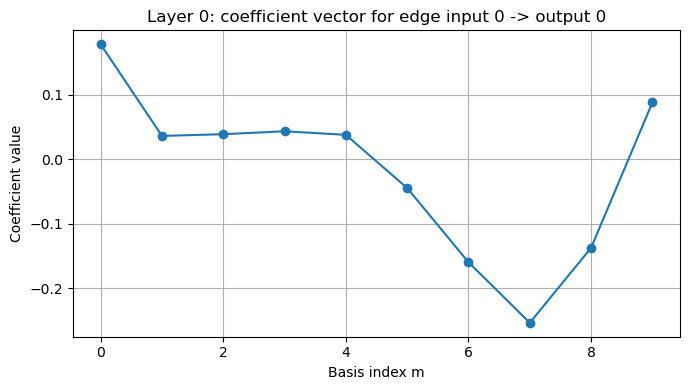

Saved MATLAB plot data to: 2-2_exports/coeff_vector_L0_out0_in1.mat


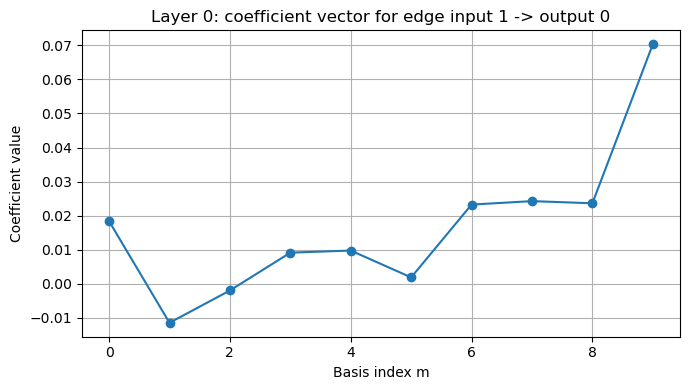

Saved MATLAB plot data to: 2-2_exports/coeff_vector_L0_out1_in0.mat


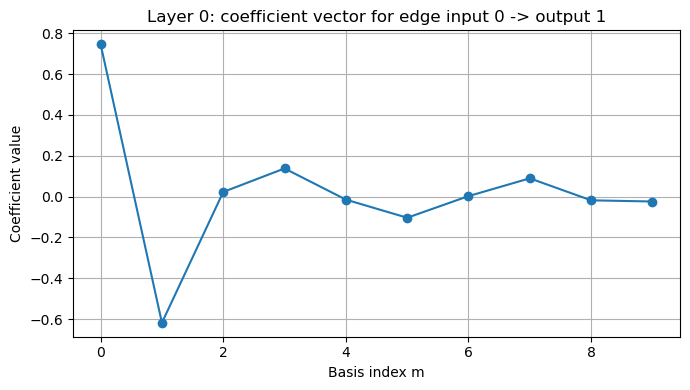

Saved MATLAB plot data to: 2-2_exports/coeff_vector_L0_out1_in1.mat


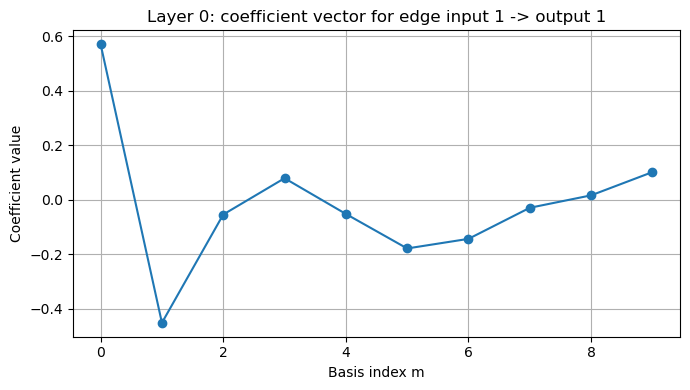

In [111]:
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=0, mat_export_path="coeff_vector_L0_out0_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=0, in_idx=1, mat_export_path="coeff_vector_L0_out0_in1.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=0, mat_export_path="coeff_vector_L0_out1_in0.mat", mat_export_dir=mat_folder)
model.plot_coefficient_vector(layer_idx=0, out_idx=1, in_idx=1, mat_export_path="coeff_vector_L0_out1_in1.mat", mat_export_dir=mat_folder)

Saved MATLAB plot data to: 2-2_exports/target_approx_varied_x0.mat


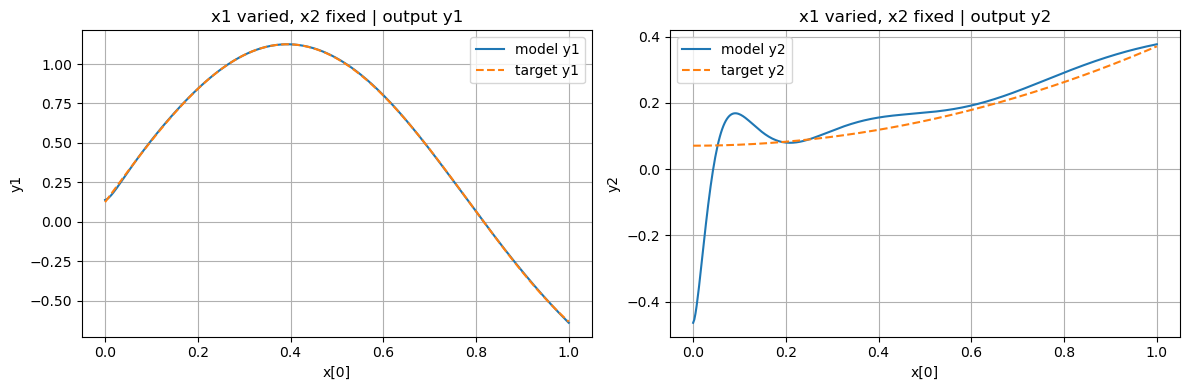

Saved MATLAB plot data to: 2-2_exports/target_approx_varied_x1.mat


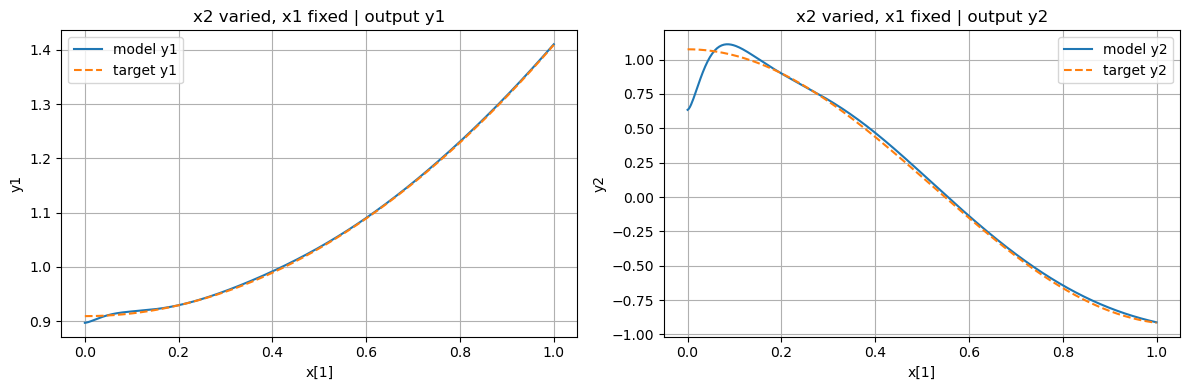

In [112]:
model.plot_target_approximation(
    target_fn=target_fn,
    x_range=(x_min_test, x_max_test),
    fixed_values=[
        0.5 * (x_min_test + x_max_test),
        0.5 * (x_min_test + x_max_test),
    ],
    mat_export_prefix="target_approx",
    mat_export_dir=mat_folder,
)